In [198]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, Dropout
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import VGG16

Image download: bing image download and icrawler completed around total 160 pictures downloading

**No success**: 
 - google_images_download
 - pexels and unsplash either. 


##### Download images for each celebrity

In [ ]:
from bing_image_downloader import downloader

def download_images(query, limit=80):
    downloader.download(query, limit=limit, output_dir='C:/Users/lily/Desktop/IT alapok privát/DEEP LEARNING/Deep Learning project/Celebrity project', adult_filter_off=True, force_replace=False, timeout=60)

celebrities = ["Leonardo DiCaprio", "Ben Affleck", "Taylor Swift", "Scarlett Johansson"]

In [105]:
for celebrity in celebrities:
    download_images(celebrity, limit=80)

[%] Downloading Images to C:\Users\lily\Desktop\IT alapok privát\DEEP LEARNING\Deep Learning project\Celebrity project\Taylor Swift


[!!]Indexing page: 1

[%] Indexed 95 Images on Page 1.


[%] Downloading Image #1 from https://m.media-amazon.com/images/M/MV5BZGM0YjhkZmEtNGYxYy00OTk0LThlNDgtNGQzM2YwNjU0NDQzXkEyXkFqcGdeQXVyMTU3ODQxNDYz._V1_.jpg
[%] File Downloaded !

[%] Downloading Image #2 from https://www.datocms-assets.com/39109/1611064879-1607718432474244-taylor-swift-re-recording-old-albums.jpg?auto=format,compress
[%] File Downloaded !

[%] Downloading Image #3 from https://celebmafia.com/wp-content/uploads/2017/11/taylor-swift-headshot-2017-7.jpg
[%] File Downloaded !

[%] Downloading Image #4 from https://media1.popsugar-assets.com/files/thumbor/Tq8cYfRf0JsW368DeSAd3jlMIX0/996x0:3652x2656/fit-in/2048xorig/filters:format_auto-!!-:strip_icc-!!-/2022/10/21/776/n/1922283/7a84031d6352d925546e24.20632319_/i/Who-Taylor-Swift-Songs-About.jpg
[%] File Downloaded !

[%] Downloading Imag

In [261]:
train_dir = "C:/Users/lily/Desktop/IT alapok privát/DEEP LEARNING/Deep Learning project/Celebrity project\Training"
test_dir = "C:/Users/lily/Desktop/IT alapok privát/DEEP LEARNING/Deep Learning project/Celebrity project\Testing"

In [262]:
BATCH_SIZE = 16
IMG_SHAPE  = 224

*Note: Data augmentation to be performed due to small number of images.*

#### Data Augmentation

##### Training data augmentation

In [263]:
train_datagen = ImageDataGenerator(
    rescale=1./255,              
    rotation_range=20,           
    width_shift_range=0.2,       
    height_shift_range=0.2,      
    shear_range=0.2,           
    zoom_range=0.2,     
    horizontal_flip=True,        
    brightness_range=[0.8, 1.2], 
    fill_mode='nearest'
)


In [264]:
images, labels = next(train_generator)

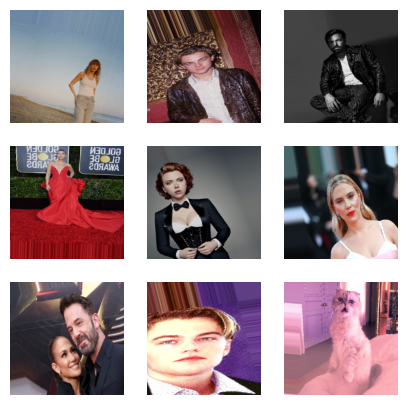

In [265]:
plt.figure(figsize=(5,5))
for i in range(9):  
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')  
plt.show()

##### Loading the training data

In [266]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SHAPE, IMG_SHAPE),  
    batch_size=BATCH_SIZE,            
    class_mode='categorical'  
)

Found 556 images belonging to 4 classes.


##### Rescaling test data

In [267]:
test_datagen = ImageDataGenerator(rescale=1./255)

##### Test data load

In [268]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SHAPE, IMG_SHAPE),   
    batch_size=BATCH_SIZE,            
    class_mode='categorical'  
)

Found 54 images belonging to 4 classes.


#### CNN modelling

In [269]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

*Note for myself: Global Average Pooling: This replaces the flattening operation, making the model simpler and less prone to overfitting by reducing the number of parameters.*

In [270]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [271]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    epochs=10  
)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 823ms/step - accuracy: 0.2728 - loss: 1.3797 - val_accuracy: 0.2292 - val_loss: 1.3907
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1250 - loss: 1.4578 - val_accuracy: 0.3333 - val_loss: 1.3574
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 33s 811ms/step - accuracy: 0.2963 - loss: 1.3548 - val_accuracy: 0.2917 - val_loss: 1.3830
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3125 - loss: 1.3772 - val_accuracy: 0.1667 - val_loss: 1.3928
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 33s 822ms/step - accuracy: 0.3231 - loss: 1.3590 - val_accuracy: 0.2083 - val_loss: 1.4094
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1250 - loss: 1.3528 - val_accuracy: 0.3333 - val_loss: 1.3578
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 32s 814ms/step - accuracy: 0.3700 - loss: 1.3162 - val_accuracy: 0.1875 - val_loss: 1.4062
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5000 - loss: 1.3039 - val_accuracy: 0.500

In [272]:
history1 = pd.DataFrame(history.history)
history1

,accuracy,loss,val_accuracy,val_loss
0,0.303704,1.365987,0.229167,1.390666
1,0.125000,1.457779,0.333333,1.357442
2,0.288889,1.362505,0.291667,1.383009
3,0.312500,1.377240,0.166667,1.392769
4,0.325926,1.351067,0.208333,1.409387
5,0.125000,1.352783,0.333333,1.357781
6,0.368519,1.326344,0.187500,1.406182
7,0.500000,1.303892,0.500000,1.237912
8,0.370370,1.321698,0.312500,1.399462
9,0.187500,1.543534,0.166667,1.379843


*Note: Since the results are quite poor and the model is overfitting, therefore tuning needed: adjustment of the batch size, adding early stopping, making the model less complex, but in case of poor result again, transfer learning method to be implemented.*

#### Model tuning

In [273]:
train_generator_2 = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),  
    batch_size=32,            
    class_mode='categorical'  
)

Found 556 images belonging to 4 classes.


In [274]:
test_generator_2 = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),   
    batch_size=32,            
    class_mode='categorical'  
)

Found 54 images belonging to 4 classes.


In [275]:
model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [276]:
model_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [277]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


history_2 = model_2.fit(
    train_generator_2,
    validation_data=test_generator_2,
    epochs=40,
    callbacks=[early_stopping]
)

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.2972 - loss: 1.3788 - val_accuracy: 0.2407 - val_loss: 1.4027
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2896 - loss: 1.3724 - val_accuracy: 0.2407 - val_loss: 1.3968
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3037 - loss: 1.3544 - val_accuracy: 0.2407 - val_loss: 1.4002
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.2926 - loss: 1.3468 - val_accuracy: 0.2407 - val_loss: 1.3996
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3012 - loss: 1.3479 - val_accuracy: 0.2593 - val_loss: 1.3928
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3401 - loss: 1.3334 - val_accuracy: 0.2778 - val_loss: 1.4666
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3190 - loss: 1.3704 - val_accuracy: 0.2963 - val_loss: 1.3830
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3740 - loss: 1.3209 - val_accuracy: 0.2963 - val_loss:

*Note: Since the model performance is still quite low with the values around 0.25, then pre-defined models to be used.*

#### Transfer Learning - MobileNetV2

*Note: VGG16 and MobileNet were trained on datasets (like ImageNet) with a standard input size of 224x224, therefore changing the input shape.*

##### MobileNetV2

*Pre-trained models like VGG16 and MobileNet were trained on the ImageNet dataset, where images were resized to 224x224x3. This is the default input shape for these models because the models' convolutional layers are optimized for this specific input size.*

In [278]:
base_model = MobileNetV2(input_shape=(224,224, 3), include_top=False, weights='imagenet')

base_model.trainable = False  

model_3 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')  
])

model_3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [279]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


history_3 = model_3.fit(
    train_generator_2,
    validation_data=test_generator_2,
    epochs=40,
    callbacks=[early_stopping]
)

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3950 - loss: 1.4739 - val_accuracy: 0.5185 - val_loss: 1.0913
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5739 - loss: 0.9709 - val_accuracy: 0.5926 - val_loss: 0.9148
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6649 - loss: 0.7939 - val_accuracy: 0.5926 - val_loss: 0.9136
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6822 - loss: 0.7766 - val_accuracy: 0.6667 - val_loss: 0.8603
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7367 - loss: 0.6743 - val_accuracy: 0.6481 - val_loss: 0.9142
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7551 - loss: 0.6464 - val_accuracy: 0.6481 - val_loss: 0.8698
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8037 - loss: 0.5659 - val_accuracy: 0.6296 - val_loss: 0.8614
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8061 - loss: 0.4880 - val_accuracy: 0.6852 - val_loss:

In [280]:
history3 = pd.DataFrame(history_3.history)
history3

,accuracy,loss,val_accuracy,val_loss
0,0.442446,1.342979,0.518519,1.091288
1,0.609712,0.906019,0.592593,0.914798
2,0.652878,0.824368,0.592593,0.913604
3,0.696043,0.760000,0.666667,0.860302
4,0.723022,0.668200,0.648148,0.914175
5,0.748201,0.629904,0.648148,0.869834
6,0.791367,0.581295,0.629630,0.861402
7,0.785971,0.522945,0.685185,0.985535
8,0.798561,0.538041,0.685185,0.822351
9,0.785971,0.558192,0.685185,0.779762


In [281]:
test_loss, test_accuracy = model_3.evaluate(test_generator_2)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 862ms/step - accuracy: 0.7419 - loss: 0.7370
Test Loss: 0.7293564677238464, Test Accuracy: 0.7222222089767456


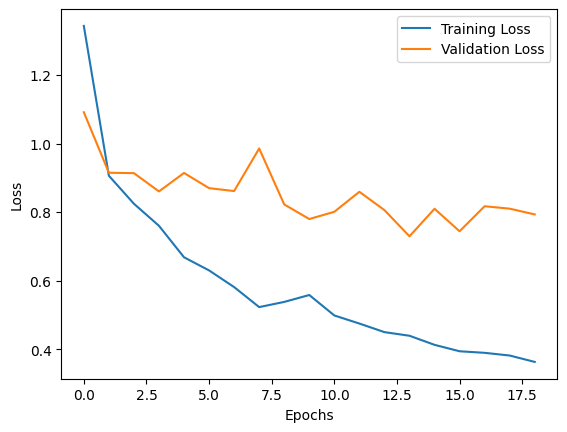

In [282]:
plt.plot(history_3.history['loss'], label='Training Loss')
plt.plot(history_3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### VGG16

**Implementation of regularization and batch normalization:**

    1. L2 Regularization: This penalizes large weights, encouraging the model to prefer smaller weights, which reduces overfitting.
    2. Batch Normalization: This normalizes the output of the previous layer, which helps to stabilize and accelerate training.

In [283]:
base_model_2 = VGG16(weights='imagenet', include_top=False, input_shape=(224,224, 3))

for layer in base_model_2.layers:
    layer.trainable = False

model_4 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax', kernel_regularizer=regularizers.l2(0.001)),
])

model_4.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [284]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


history_4 = model_4.fit(
    train_generator_2,
    validation_data=test_generator_2,
    epochs=40,
    callbacks=[early_stopping]
)

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.2990 - loss: 2.6051 - val_accuracy: 0.2593 - val_loss: 1.9758
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3232 - loss: 2.4887 - val_accuracy: 0.2963 - val_loss: 1.9315
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3520 - loss: 2.4682 - val_accuracy: 0.2963 - val_loss: 1.9026
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3299 - loss: 2.5728 - val_accuracy: 0.3148 - val_loss: 1.8818
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3442 - loss: 2.4674 - val_accuracy: 0.3148 - val_loss: 1.8668
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3124 - loss: 2.5278 - val_accuracy: 0.3704 - val_loss: 1.8567
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3403 - loss: 2.3750 - val_accuracy: 0.3519 - val_loss: 1.8498
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.3435 - loss: 2.4953 - val_accuracy: 0.3889 - val_loss:

In [285]:
history4 = pd.DataFrame(history_4.history)
history4

,accuracy,loss,val_accuracy,val_loss
0,0.289568,2.651463,0.259259,1.975762
1,0.298561,2.568319,0.296296,1.931497
2,0.320144,2.543041,0.296296,1.902572
3,0.323741,2.510778,0.314815,1.881802
4,0.334532,2.420017,0.314815,1.866847
5,0.323741,2.503565,0.370370,1.856692
6,0.356115,2.346065,0.351852,1.849840
7,0.372302,2.327280,0.388889,1.840227
8,0.384892,2.270918,0.388889,1.833356
9,0.408273,2.141224,0.388889,1.829203


In [286]:
test_loss, test_accuracy = model_3.evaluate(test_generator_2)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7315 - loss: 0.7249
Test Loss: 0.7293565273284912, Test Accuracy: 0.7222222089767456


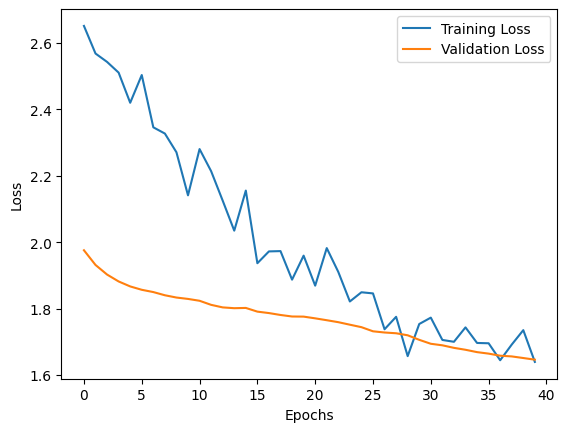

In [287]:
plt.plot(history_4.history['loss'], label='Training Loss')
plt.plot(history_4.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

##### Tuning by unfreezing

In [288]:
for layer in base_model_2.layers[-4:]:  # Unfreeze the last 4 layers
    layer.trainable = True

In [289]:
model_4.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [290]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_tuned = model_4.fit(train_generator_2, validation_data=test_generator_2, epochs=40, callbacks=[early_stopping])

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.5420 - loss: 1.6557 - val_accuracy: 0.5185 - val_loss: 1.6393
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5868 - loss: 1.6203 - val_accuracy: 0.5741 - val_loss: 1.6297
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5837 - loss: 1.5570 - val_accuracy: 0.5741 - val_loss: 1.6264
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5895 - loss: 1.4876 - val_accuracy: 0.5556 - val_loss: 1.6216
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5565 - loss: 1.5981 - val_accuracy: 0.5556 - val_loss: 1.6127
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5656 - loss: 1.5474 - val_accuracy: 0.5556 - val_loss: 1.6069
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6088 - loss: 1.4964 - val_accuracy: 0.5741 - val_loss: 1.6045
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5561 - loss: 1.5333 - val_accuracy: 0.5741 - val_loss:

In [291]:
history_t = pd.DataFrame(history_tuned.history)
history_t

,accuracy,loss,val_accuracy,val_loss
0,0.559353,1.641756,0.518519,1.639298
1,0.562950,1.631021,0.574074,1.629671
2,0.559353,1.610652,0.574074,1.626359
3,0.584532,1.524228,0.555556,1.621618
4,0.575540,1.571176,0.555556,1.612660
5,0.550360,1.574380,0.555556,1.606920
6,0.613309,1.524409,0.574074,1.604456
7,0.577338,1.582937,0.574074,1.600176
8,0.600719,1.545991,0.574074,1.595165
9,0.598921,1.501242,0.574074,1.590656


##### Unfreeze more layers

In [292]:
for layer in base_model_2.layers[-8:]:  
    layer.trainable = True

In [293]:
model_4.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [294]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_tuned2 = model_4.fit(train_generator_2, validation_data=test_generator_2, epochs=40, callbacks=[early_stopping])

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6613 - loss: 1.3477 - val_accuracy: 0.5926 - val_loss: 1.4971
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6291 - loss: 1.3359 - val_accuracy: 0.5926 - val_loss: 1.4960
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6902 - loss: 1.2869 - val_accuracy: 0.5926 - val_loss: 1.4905
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6798 - loss: 1.2720 - val_accuracy: 0.5926 - val_loss: 1.4903
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.6685 - loss: 1.2720 - val_accuracy: 0.5926 - val_loss: 1.4914
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6847 - loss: 1.2744 - val_accuracy: 0.5926 - val_loss: 1.4898
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6708 - loss: 1.2701 - val_accuracy: 0.5741 - val_loss: 1.4846
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6555 - loss: 1.2344 - val_accuracy: 0.5926 - val_loss:

##### The best val_accuracy is around 0.611 in the history_tuned2 = model_4 - there is room for improvement, but bear in mind that the size of the dataset is around 170 images per celebrities. 

To improve the performance of your model, especially given that you have a relatively small dataset, here are several strategies you could try:

**Data Augmentation**: Even though you’ve collected more images, 170 per class is still considered small for training deep neural networks. Augment your data with transformations such as random rotations, shifts, zooms, flips, and brightness changes. This will artificially increase the dataset size and help the model generalize better.

**Fine-Tuning More Layers**: If unfreezing just a few layers didn’t improve results significantly, try unfreezing more layers for fine-tuning. The initial layers of models like VGG16 or MobileNet capture more general features, while the later layers capture task-specific details. Fine-tuning more layers might help if the model hasn't adapted enough to your specific data.

**Experiment with Other Architectures**: Consider experimenting with other models like EfficientNet or ResNet, which may perform better on small datasets or adapt more quickly to your data.

**Adjusting Learning Rate**: Fine-tune the learning rate during training. A smaller learning rate after unfreezing layers might help the model converge better and avoid overfitting.

**Regularization**: Use techniques like dropout, L2 regularization, or batch normalization. These can help prevent overfitting and improve performance on your small dataset.

**Ensemble Models**: You can try using ensemble methods by combining predictions from multiple models like MobileNet, VGG16, and others. Ensemble models often perform better than individual models.

**More Training Data**: If possible, continue expanding your dataset by manually adding more images or leveraging other tools to scrape reliable sources for celebrity images.

**Transfer Learning with Pretrained Models on Similar Data**: Instead of general pretrained models, you could look for models already trained on face datasets (like FaceNet or models from face recognition libraries) and fine-tune them on your celebrity dataset.

If the issue persists even after these adjustments, it might be helpful to look at your training process for potential issues such as class imbalance, image quality, or label noise.